# Project 3 — Early Warning System for Sepsis (PhysioNet 2019)
## Notebook 05 — Advanced Alert Policies (Persistence) + Honest Tradeoffs (PhD-level)

This notebook upgrades the early warning system with a **persistence alert policy** to reduce alarm fatigue:

**Policy B (K-of-M persistence + lockout)**
- Maintain a rolling window of the last **M** hours of `p_cal >= τ`
- Trigger an alert only if the count in the window is **≥ K**
- After alerting, apply a **lockout** period (no further alerts for `lockout_hours`)

### Why this matters
Single-threshold “first crossing” can be sensitive to spikes and missingness artifacts.  
Persistence makes alerting **more clinically deployable**.

### Inputs
- `results/oof_with_calibration.parquet` (Notebook 04 output, includes `p_cal`)
- `results/threshold_sweep_policyA.csv` (Notebook 04 output, Policy A sweep)

### Outputs
- `results/threshold_sweep_policyB.csv`
- `results/policyB_selected.json`  (contains **two** operating points: low-alarm & high-detection)
- figures in `figures/`:
  - `policyA_vs_policyB_detection_tradeoff.png`
  - `policyA_vs_policyB_lead_burden_tradeoff.png`


In [31]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)

# -------------------------
# Paths (EDIT THIS ONCE)
# -------------------------
PROJECT_ROOT = Path(".").resolve()
DATA_ROOT = PROJECT_ROOT  # set this if your results live elsewhere

RESULTS_DIR = DATA_ROOT / "results"
FIG_DIR = DATA_ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

IN_OOF_CAL = RESULTS_DIR / "oof_with_calibration.parquet"
IN_SWEEP_A = RESULTS_DIR / "threshold_sweep_policyA.csv"

SWEEP_A_PATH = IN_SWEEP_A_V3 if IN_SWEEP_A_V3.exists() else IN_SWEEP_A
print("Using Policy A sweep:", SWEEP_A_PATH)

OUT_SWEEP_B = RESULTS_DIR / "threshold_sweep_policyB.csv"
OUT_SELECTED = RESULTS_DIR / "policyB_selected.json"

print("OOF calibrated exists:", IN_OOF_CAL.exists(), IN_OOF_CAL)
print("Sweep A exists:", IN_SWEEP_A.exists(), IN_SWEEP_A)


Using Policy A sweep: C:\Users\Admin\anaconda_projects\f41dcae4-d989-44e3-8a04-984a86780085\notebooks\results\threshold_sweep_policyA.csv
OOF calibrated exists: True C:\Users\Admin\anaconda_projects\f41dcae4-d989-44e3-8a04-984a86780085\notebooks\results\oof_with_calibration.parquet
Sweep A exists: True C:\Users\Admin\anaconda_projects\f41dcae4-d989-44e3-8a04-984a86780085\notebooks\results\threshold_sweep_policyA.csv


### 1) Load calibrated OOF predictions
We expect at least:
- `patient_id`, `ICULOS`, `y`, `p_cal`, `sepsis_any`, `event_iculos`


In [32]:
df = pd.read_parquet(IN_OOF_CAL)
df = df.sort_values(["patient_id", "ICULOS"]).reset_index(drop=True)

required = {"patient_id", "ICULOS", "y", "p_cal", "sepsis_any", "event_iculos"}
missing = required - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

n_sepsis = int(df.drop_duplicates("patient_id")["sepsis_any"].sum())
n_pat = int(df["patient_id"].nunique())
print("Rows:", len(df), "Patients:", n_pat, "Sepsis patients:", n_sepsis)
df.head()


Rows: 19145 Patients: 493 Sepsis patients: 39


,patient_id,ICULOS,y,p_oof,fold_id,model_name,sepsis_any,event_iculos,p_cal
0,p000214,2,0,0.000250,4,hgb,0,NaN,0.0
1,p000214,3,0,0.000241,4,hgb,0,NaN,0.0
2,p000214,4,0,0.000262,4,hgb,0,NaN,0.0
3,p000214,5,0,0.000262,4,hgb,0,NaN,0.0
4,p000214,6,0,0.000262,4,hgb,0,NaN,0.0


### 2) Policy B: K-of-M persistence + lockout
Implementation notes:
- We evaluate on **patient groups** (no mixing).
- We report patient-level detection (alert before onset), lead-time, and alarm burden.


In [33]:
def policy_persistence_k_of_m(df_patient: pd.DataFrame,
                               prob_col: str,
                               tau: float,
                               K: int,
                               M: int,
                               lockout_hours: int = 6):
    g = df_patient.sort_values("ICULOS")
    t_arr = g["ICULOS"].values.astype(float)
    p_arr = g[prob_col].values.astype(float)

    hits = (p_arr >= tau).astype(int)

    alert_times = []
    next_allowed = -np.inf

    window = []
    window_sum = 0

    for t, h in zip(t_arr, hits):
        # maintain last M observations (including current time)
        window.append(int(h))
        window_sum += int(h)
        if len(window) > M:
            window_sum -= window.pop(0)

        if t < next_allowed:
            continue

        if window_sum >= K:
            alert_times.append(float(t))
            next_allowed = float(t) + lockout_hours

            # reset window after alert to avoid immediate retrigger
            window = []
            window_sum = 0

    return alert_times

def evaluate_policy_B(df_all: pd.DataFrame,
                      tau: float,
                      K: int,
                      M: int,
                      lockout_hours: int = 6,
                      prob_col: str = "p_cal"):
    total_hours = float(len(df_all))
    patient_table = df_all.drop_duplicates("patient_id")[["patient_id", "sepsis_any"]]
    n_patients = int(patient_table.shape[0])
    n_sepsis = int(patient_table["sepsis_any"].sum())
    n_nonsepsis = int(n_patients - n_sepsis)

    sepsis_detected = 0
    lead_times = []
    lead_ge_1 = lead_ge_3 = lead_ge_6 = 0

    nonsepsis_alerted = 0
    total_alerts = 0

    for pid, g in df_all.groupby("patient_id", sort=False):
        sepsis_any = int(g["sepsis_any"].iloc[0])
        onset = g["event_iculos"].iloc[0]

        alert_times = policy_persistence_k_of_m(
            g, prob_col=prob_col, tau=tau, K=K, M=M, lockout_hours=lockout_hours
        )
        total_alerts += len(alert_times)

        if sepsis_any == 0:
            if len(alert_times) > 0:
                nonsepsis_alerted += 1
            continue

        if len(alert_times) == 0 or pd.isna(onset):
            continue

        first_alert = alert_times[0]
        lead = float(onset) - float(first_alert)
        lead_times.append(lead)

        if lead > 0:
            sepsis_detected += 1
        if lead >= 1: lead_ge_1 += 1
        if lead >= 3: lead_ge_3 += 1
        if lead >= 6: lead_ge_6 += 1

    alerts_per_100h = (total_alerts / total_hours) * 100.0

    return {
        "policy": "B_persistence",
        "tau": float(tau),
        "K": int(K),
        "M": int(M),
        "lockout_hours": int(lockout_hours),
        "n_patients": n_patients,
        "n_sepsis": n_sepsis,
        "n_nonsepsis": n_nonsepsis,
        "sepsis_detected": int(sepsis_detected),
        "sepsis_detection_rate": float(sepsis_detected / n_sepsis) if n_sepsis else np.nan,
        "nonsepsis_alerted": int(nonsepsis_alerted),
        "nonsepsis_alert_rate": float(nonsepsis_alerted / n_nonsepsis) if n_nonsepsis else np.nan,
        "alerts_total": int(total_alerts),
        "alerts_per_100_patient_hours": float(alerts_per_100h),
        "lead_time_median": float(np.nanmedian(lead_times)) if len(lead_times) else np.nan,
        "lead_time_mean": float(np.nanmean(lead_times)) if len(lead_times) else np.nan,
        "lead_ge_1_rate": float(lead_ge_1 / n_sepsis) if n_sepsis else np.nan,
        "lead_ge_3_rate": float(lead_ge_3 / n_sepsis) if n_sepsis else np.nan,
        "lead_ge_6_rate": float(lead_ge_6 / n_sepsis) if n_sepsis else np.nan,
    }


### 3) Threshold sweep for Policy B
We evaluate a small grid of persistence settings (K,M) and thresholds.

Recommended combos:
- **2-of-4**
- **3-of-6**


In [34]:
LOCKOUT_HOURS = 6

KM_LIST = [(2, 4), (3, 6)]  # (K, M)

TAUS = np.unique(np.concatenate([
    np.linspace(0.005, 0.05, 30),
    np.linspace(0.05, 0.15, 80),   # action zone (dense)
    np.linspace(0.15, 0.50, 30),
    np.linspace(0.50, 0.95, 10),
]))

rows = []
for (K, M) in KM_LIST:
    for tau in TAUS:
        rows.append(evaluate_policy_B(df, tau=float(tau), K=K, M=M, lockout_hours=LOCKOUT_HOURS, prob_col="p_cal"))

sweepB = pd.DataFrame(rows)
sweepB["policy_name"] = sweepB.apply(lambda r: f"B_{int(r['K'])}of{int(r['M'])}", axis=1)

sweepB.to_csv(OUT_SWEEP_B, index=False)
print("Saved:", OUT_SWEEP_B)
sweepB.head()


Saved: C:\Users\Admin\anaconda_projects\f41dcae4-d989-44e3-8a04-984a86780085\notebooks\results\threshold_sweep_policyB.csv


,policy,tau,K,M,lockout_hours,n_patients,n_sepsis,n_nonsepsis,sepsis_detected,sepsis_detection_rate,nonsepsis_alerted,nonsepsis_alert_rate,alerts_total,alerts_per_100_patient_hours,lead_time_median,lead_time_mean,lead_ge_1_rate,lead_ge_3_rate,lead_ge_6_rate,policy_name
0,B_persistence,0.005000,2,4,6,493,39,454,37,0.948718,5,0.011013,415,2.167668,64.0,68.513514,0.948718,0.897436,0.846154,B_2of4
1,B_persistence,0.006552,2,4,6,493,39,454,37,0.948718,5,0.011013,415,2.167668,64.0,68.513514,0.948718,0.897436,0.846154,B_2of4
2,B_persistence,0.008103,2,4,6,493,39,454,37,0.948718,5,0.011013,415,2.167668,64.0,68.513514,0.948718,0.897436,0.846154,B_2of4
3,B_persistence,0.009655,2,4,6,493,39,454,37,0.948718,5,0.011013,415,2.167668,64.0,68.513514,0.948718,0.897436,0.846154,B_2of4
4,B_persistence,0.011207,2,4,6,493,39,454,37,0.948718,5,0.011013,415,2.167668,64.0,68.513514,0.948718,0.897436,0.846154,B_2of4


### 4) Load Policy A sweep and compare (honest plots)
Two important plotting fixes:
1) **Zoom / log-ish x-axis** for false alerts because values are tiny.
2) For lead-time vs burden, **filter out extremely low detection** (otherwise medians can look misleading).


In [35]:
sweepA = pd.read_csv(SWEEP_A_PATH)
sweepA["policy_name"] = "A_first_crossing"

needA = {"tau", "sepsis_detection_rate", "nonsepsis_alert_rate", "alerts_per_100_patient_hours", "lead_time_median"}
assert needA.issubset(set(sweepA.columns)), f"Policy A sweep missing columns: {needA - set(sweepA.columns)}"

sweepA.head()


,tau,lockout_hours,n_patients,n_sepsis,n_nonsepsis,sepsis_detected,sepsis_detection_rate,nonsepsis_alerted,nonsepsis_alert_rate,alerts_total,alerts_per_100_patient_hours,lead_time_median,lead_time_mean,lead_ge_1_rate,lead_ge_3_rate,lead_ge_6_rate,policy_name
0,0.010000,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154,A_first_crossing
1,0.014737,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154,A_first_crossing
2,0.019474,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154,A_first_crossing
3,0.024211,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154,A_first_crossing
4,0.028947,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154,A_first_crossing


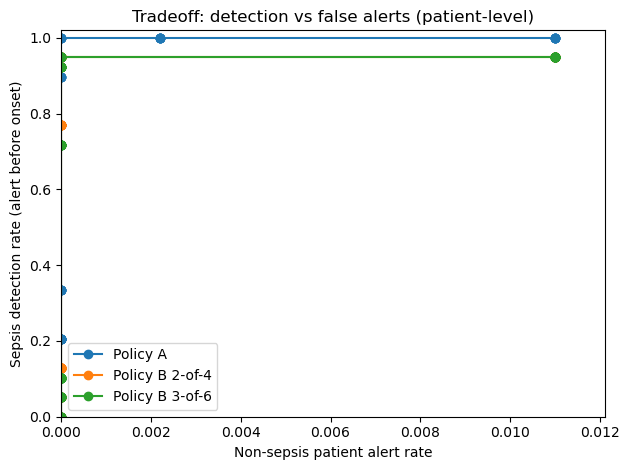

In [36]:
# -------- Plot 1: detection vs false alerts (patient-level) --------
plt.figure()
plt.plot(sweepA["nonsepsis_alert_rate"], sweepA["sepsis_detection_rate"], marker="o", linestyle="-", label="Policy A")

for (K, M) in KM_LIST:
    sub = sweepB[(sweepB["K"] == K) & (sweepB["M"] == M)]
    plt.plot(sub["nonsepsis_alert_rate"], sub["sepsis_detection_rate"], marker="o", linestyle="-", label=f"Policy B {K}-of-{M}")

plt.xlabel("Non-sepsis patient alert rate")
plt.ylabel("Sepsis detection rate (alert before onset)")
plt.title("Tradeoff: detection vs false alerts (patient-level)")
plt.legend()

# Zoom-in for readability (false alert rates are tiny)
xmax = max(
    float(sweepA["nonsepsis_alert_rate"].max()),
    float(sweepB["nonsepsis_alert_rate"].max()),
    1e-6
)
plt.xlim(0, min(0.02, xmax * 1.1))  # cap at 2% unless larger
plt.ylim(0, 1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / "policyA_vs_policyB_detection_tradeoff.png", dpi=200)
plt.show()


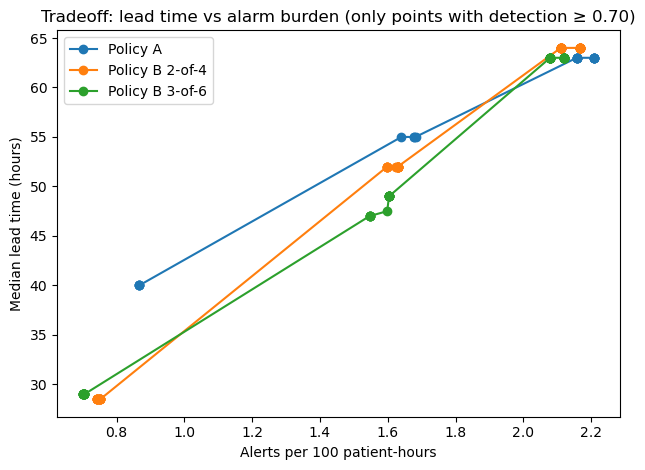

In [37]:
# -------- Plot 2: lead time vs burden (filter low detection) --------
MIN_DET_FOR_PLOT = 0.70  # hide very-low detection points

plt.figure()

A_plot = sweepA[sweepA["sepsis_detection_rate"] >= MIN_DET_FOR_PLOT].copy()
plt.plot(A_plot["alerts_per_100_patient_hours"], A_plot["lead_time_median"], marker="o", linestyle="-", label="Policy A")

for (K, M) in KM_LIST:
    sub = sweepB[(sweepB["K"] == K) & (sweepB["M"] == M) & (sweepB["sepsis_detection_rate"] >= MIN_DET_FOR_PLOT)].copy()
    plt.plot(sub["alerts_per_100_patient_hours"], sub["lead_time_median"], marker="o", linestyle="-", label=f"Policy B {K}-of-{M}")

plt.xlabel("Alerts per 100 patient-hours")
plt.ylabel("Median lead time (hours)")
plt.title(f"Tradeoff: lead time vs alarm burden (only points with detection ≥ {MIN_DET_FOR_PLOT:.2f})")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "policyA_vs_policyB_lead_burden_tradeoff.png", dpi=200)
plt.show()


### 5) Select operating points for Policy B (two modes)

To make the system *deployable* and *defensible*, we select **two** operating points:

**Mode 1 — Low-alarm (default)**
- constraints:
  - non-sepsis alert rate ≤ `MAX_FALSE_ALERT`
  - alerts per 100 patient-hours ≤ `MAX_ALERTS_PER_100H`
- objective: maximize detection, then lead time

**Mode 2 — High-detection**
- constraints:
  - detection ≥ `MIN_DET_HIGH`
  - non-sepsis alert rate ≤ `MAX_FALSE_ALERT_HIGH`
- objective: minimize alarm burden, then maximize lead time

This gives you a clean “two-mode” clinical story.


In [38]:
MAX_FALSE_ALERT = 0.10
MAX_ALERTS_PER_100H = 1.0

MIN_DET_HIGH = 0.90
MAX_FALSE_ALERT_HIGH = 0.02  # allow up to 2% non-sepsis patient alerts for high-sensitivity mode

def select_low_alarm(sweepB: pd.DataFrame):
    feasible = sweepB[(sweepB["nonsepsis_alert_rate"] <= MAX_FALSE_ALERT) &
                      (sweepB["alerts_per_100_patient_hours"] <= MAX_ALERTS_PER_100H)].copy()
    if feasible.empty:
        chosen = sweepB.sort_values(["sepsis_detection_rate", "lead_time_median"], ascending=False).head(1)
    else:
        chosen = feasible.sort_values(["sepsis_detection_rate", "lead_time_median"], ascending=False).head(1)
    return chosen.iloc[0].to_dict()

def select_high_detection(sweepB: pd.DataFrame):
    feasible = sweepB[(sweepB["sepsis_detection_rate"] >= MIN_DET_HIGH) &
                      (sweepB["nonsepsis_alert_rate"] <= MAX_FALSE_ALERT_HIGH)].copy()
    if feasible.empty:
        # fallback: just maximize detection then minimize burden
        chosen = sweepB.sort_values(["sepsis_detection_rate", "alerts_per_100_patient_hours"], ascending=[False, True]).head(1)
    else:
        chosen = feasible.sort_values(["alerts_per_100_patient_hours", "lead_time_median"], ascending=[True, False]).head(1)
    return chosen.iloc[0].to_dict()

op_low_alarm = select_low_alarm(sweepB)
op_high_det  = select_high_detection(sweepB)

op_low_alarm, op_high_det


({'policy': 'B_persistence',
  'tau': 0.08544303797468354,
  'K': 2,
  'M': 4,
  'lockout_hours': 6,
  'n_patients': 493,
  'n_sepsis': 39,
  'n_nonsepsis': 454,
  'sepsis_detected': 30,
  'sepsis_detection_rate': 0.7692307692307693,
  'nonsepsis_alerted': 0,
  'nonsepsis_alert_rate': 0.0,
  'alerts_total': 144,
  'alerts_per_100_patient_hours': 0.7521546095586316,
  'lead_time_median': 28.5,
  'lead_time_mean': 44.2,
  'lead_ge_1_rate': 0.7692307692307693,
  'lead_ge_3_rate': 0.6923076923076923,
  'lead_ge_6_rate': 0.6410256410256411,
  'policy_name': 'B_2of4'},
 {'policy': 'B_persistence',
  'tau': 0.07911392405063292,
  'K': 3,
  'M': 6,
  'lockout_hours': 6,
  'n_patients': 493,
  'n_sepsis': 39,
  'n_nonsepsis': 454,
  'sepsis_detected': 36,
  'sepsis_detection_rate': 0.9230769230769231,
  'nonsepsis_alerted': 0,
  'nonsepsis_alert_rate': 0.0,
  'alerts_total': 296,
  'alerts_per_100_patient_hours': 1.5460955863149648,
  'lead_time_median': 47.0,
  'lead_time_mean': 57.25,
  'lead

### 6) Compare chosen Policy B points to closest Policy A points (same detection)
This produces an interview-ready summary:
- “At similar detection, persistence reduces alert burden by X%”


In [39]:
def match_policyA_fair(sweepA: pd.DataFrame, target_det: float, tol: float = 0.01):
    """
    Fair matching:
    1) Prefer A points with detection >= (target_det - tol), choose MIN burden, then MAX lead.
    2) If none exist, pick closest detection (abs gap), then MIN burden, then MAX lead.
    """
    cand = sweepA[sweepA["sepsis_detection_rate"] >= (target_det - tol)].copy()
    if not cand.empty:
        cand = cand.sort_values(["alerts_per_100_patient_hours", "lead_time_median"], ascending=[True, False])
        return cand.iloc[0].to_dict()

    tmp = sweepA.copy()
    tmp["det_gap"] = (tmp["sepsis_detection_rate"] - target_det).abs()
    tmp = tmp.sort_values(["det_gap", "alerts_per_100_patient_hours", "lead_time_median"],
                          ascending=[True, True, False])
    return tmp.iloc[0].to_dict()

A_for_low  = match_policyA_fair(sweepA, float(op_low_alarm["sepsis_detection_rate"]), tol=0.01)
A_for_high = match_policyA_fair(sweepA, float(op_high_det["sepsis_detection_rate"]), tol=0.01)

def summarize_compare(A_row, B_row):
    # percent reduction in burden: positive means B is better (lower burden)
    A_burden = float(A_row["alerts_per_100_patient_hours"])
    B_burden = float(B_row["alerts_per_100_patient_hours"])
    burden_reduction = (A_burden - B_burden) / A_burden if A_burden > 0 else np.nan

    return {
        "A_tau": float(A_row["tau"]),
        "A_det": float(A_row["sepsis_detection_rate"]),
        "A_false": float(A_row["nonsepsis_alert_rate"]),
        "A_burden": A_burden,
        "A_lead_med": float(A_row["lead_time_median"]),
        "B_policy": str(B_row.get("policy_name", "B")),
        "B_tau": float(B_row["tau"]),
        "B_K": int(B_row["K"]),
        "B_M": int(B_row["M"]),
        "B_det": float(B_row["sepsis_detection_rate"]),
        "B_false": float(B_row["nonsepsis_alert_rate"]),
        "B_burden": B_burden,
        "B_lead_med": float(B_row["lead_time_median"]),
        "burden_reduction_frac": float(burden_reduction) if burden_reduction == burden_reduction else np.nan,
    }

compare_low  = summarize_compare(A_for_low, op_low_alarm)
compare_high = summarize_compare(A_for_high, op_high_det)

compare_low, compare_high


({'A_tau': 0.0857894736842105,
  'A_det': 0.8974358974358975,
  'A_false': 0.0,
  'A_burden': 0.8670671193523114,
  'A_lead_med': 40.0,
  'B_policy': 'B_2of4',
  'B_tau': 0.08544303797468354,
  'B_K': 2,
  'B_M': 4,
  'B_det': 0.7692307692307693,
  'B_false': 0.0,
  'B_burden': 0.7521546095586316,
  'B_lead_med': 28.5,
  'burden_reduction_frac': 0.13253012048192772},
 {'A_tau': 0.0810526315789473,
  'A_det': 1.0,
  'A_false': 0.0,
  'A_burden': 1.6401149125097936,
  'A_lead_med': 55.0,
  'B_policy': 'B_3of6',
  'B_tau': 0.07911392405063292,
  'B_K': 3,
  'B_M': 6,
  'B_det': 0.9230769230769231,
  'B_false': 0.0,
  'B_burden': 1.5460955863149648,
  'B_lead_med': 47.0,
  'burden_reduction_frac': 0.057324840764331114})

### 7) Save selection summary (two-mode policy)
We store both operating points + comparisons to Policy A in one JSON.


In [40]:
selected = {
    "policyB_low_alarm": op_low_alarm,
    "policyB_high_detection": op_high_det,
    "closest_policyA_for_low_alarm": A_for_low,
    "closest_policyA_for_high_detection": A_for_high,
    "comparison_low_alarm": compare_low,
    "comparison_high_detection": compare_high,
    "selection_rules": {
        "low_alarm": {
            "MAX_FALSE_ALERT": MAX_FALSE_ALERT,
            "MAX_ALERTS_PER_100H": MAX_ALERTS_PER_100H,
            "objective": "max detection then max lead time",
        },
        "high_detection": {
            "MIN_DET_HIGH": MIN_DET_HIGH,
            "MAX_FALSE_ALERT_HIGH": MAX_FALSE_ALERT_HIGH,
            "objective": "min burden then max lead time",
        }
    }
}

OUT_SELECTED.write_text(json.dumps(selected, indent=2))
print("Saved:", OUT_SELECTED)
selected


Saved: C:\Users\Admin\anaconda_projects\f41dcae4-d989-44e3-8a04-984a86780085\notebooks\results\policyB_selected.json


{'policyB_low_alarm': {'policy': 'B_persistence',
  'tau': 0.08544303797468354,
  'K': 2,
  'M': 4,
  'lockout_hours': 6,
  'n_patients': 493,
  'n_sepsis': 39,
  'n_nonsepsis': 454,
  'sepsis_detected': 30,
  'sepsis_detection_rate': 0.7692307692307693,
  'nonsepsis_alerted': 0,
  'nonsepsis_alert_rate': 0.0,
  'alerts_total': 144,
  'alerts_per_100_patient_hours': 0.7521546095586316,
  'lead_time_median': 28.5,
  'lead_time_mean': 44.2,
  'lead_ge_1_rate': 0.7692307692307693,
  'lead_ge_3_rate': 0.6923076923076923,
  'lead_ge_6_rate': 0.6410256410256411,
  'policy_name': 'B_2of4'},
 'policyB_high_detection': {'policy': 'B_persistence',
  'tau': 0.07911392405063292,
  'K': 3,
  'M': 6,
  'lockout_hours': 6,
  'n_patients': 493,
  'n_sepsis': 39,
  'n_nonsepsis': 454,
  'sepsis_detected': 36,
  'sepsis_detection_rate': 0.9230769230769231,
  'nonsepsis_alerted': 0,
  'nonsepsis_alert_rate': 0.0,
  'alerts_total': 296,
  'alerts_per_100_patient_hours': 1.5460955863149648,
  'lead_time_me

## Done ✅

You now have a clean, defensible story:
- **Policy A (Notebook 04):** first crossing + lockout
- **Policy B (Notebook 05):** persistence + lockout, with two operating modes

Next optional PhD upgrades:
- utility-based threshold selection (FP/FN/delay costs)
- subgroup drift tests (LOS quartiles, missingness burden)
